# 09. Score Calibration Ablation

## 1. 분석 목적

이번 분석의 핵심 질문은 다음과 같다.

> Base Similarity와 Community Similarity를 numerical scale이 비교 가능한 형태로 보정한 뒤에도 Season / Daypart Community 정보가 향 구조 기반 Ranking에 추가적인 성능을 제공하는가?

새로운 feature는 추가하지 않는다. Candidate Pool은 200으로 고정하고, Raw Accord Cosine + IDF Weighted Union Note Jaccard(0.5 : 0.5), Reliable vote ≥ 20인 Season + Daypart Community, reminds_me_of Relevant Pair, Development / Final Holdout split을 그대로 재현한다. 변경 요소는 **Score Calibration 방식**뿐이다.

Final Holdout 300개는 candidate 생성, gamma 선택, 성능 평가, 해석에 사용하지 않는다. gamma는 feature 중요도의 인과적 비율이 아니라 **현재 score 표현에서 Development ranking 성능을 최적화한 결합 계수**로 해석한다.

## 2. 환경 설정

In [1]:
import array
import collections
import gc
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from scipy.stats import pearsonr, rankdata, spearmanr
from tqdm import tqdm

SEED = 42
N_FOLDS = 5
BATCH_SIZE = 8
CANDIDATE_POOL = 200
GAMMAS = np.round(np.arange(0.0, 1.001, 0.05), 2)
METHODS = ("RAW", "MINMAX", "ZSCORE", "PERCENTILE")
CALIBRATED_METHODS = ("MINMAX", "ZSCORE", "PERCENTILE")
TOP_KS = (10, 20)
REPORT_METRICS = ["Recall@10", "HitRate@10", "MRR@10", "NDCG@10", "Recall@20", "NDCG@20"]
BOOTSTRAP_RESAMPLES = 2000
PRACTICAL_TOLERANCE = 0.002
SEASON_NAMES = ("winter", "spring", "summer", "autumn")
DAYPART_NAMES = ("day", "night")

jsonl_path = pathlib.Path.cwd() / "perfumes.jsonl"
assert jsonl_path.is_file(), f"파일을 찾을 수 없습니다: {jsonl_path}"
print(f"데이터: {jsonl_path.name} ({jsonl_path.stat().st_size / (1024 ** 2):,.2f} MB)")
print(f"고정 Candidate Pool: {CANDIDATE_POOL}")
print(f"gamma grid: {GAMMAS.tolist()}")

데이터: perfumes.jsonl (485.94 MB)
고정 Candidate Pool: 200
gamma grid: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]


## 3. 데이터 로드

In [2]:
perfume_ids = array.array("i")
perfume_names, perfume_brands = [], []
popularity_values = array.array("f")
has_accord, has_note = array.array("b"), array.array("b")

accord_to_col = {}
accord_rows, accord_cols, accord_data = array.array("I"), array.array("I"), array.array("f")
note_to_col = {}
note_rows, note_cols = array.array("I"), array.array("I")
season_vote_rows, daypart_vote_rows = [], []

relation_source_ids, relation_target_ids = array.array("i"), array.array("i")
relation_up_votes, relation_down_votes = array.array("i"), array.array("i")

with jsonl_path.open("r", encoding="utf-8") as file:
    for line in tqdm(file, desc="JSONL load", unit=" perfumes", mininterval=2.0):
        if not line.strip():
            continue
        row_index = len(perfume_ids)
        record = json.loads(line)
        perfume_id = int(record["id"])
        perfume_ids.append(perfume_id)
        perfume_names.append(record.get("name") or "")
        perfume_brands.append(record.get("brand") or "")

        magnitude = (record.get("popularity") or {}).get("magnitude")
        popularity_values.append(float(magnitude) if magnitude is not None else np.nan)

        accord_strengths = {}
        for item in record.get("accords") or []:
            name, strength = item.get("name"), item.get("strength")
            if name and strength is not None:
                col = accord_to_col.setdefault(name, len(accord_to_col))
                accord_strengths[col] = float(strength)
        has_accord.append(bool(accord_strengths))
        for col, strength in accord_strengths.items():
            accord_rows.append(row_index)
            accord_cols.append(col)
            accord_data.append(strength)

        notes = record.get("notes") or {}
        tiered = notes.get("tiered") or {}
        note_names = set()
        for position in ("top", "middle", "base"):
            note_names.update(item.get("name") for item in tiered.get(position) or [] if item.get("name"))
        note_names.update(item.get("name") for item in notes.get("flat") or [] if item.get("name"))
        has_note.append(bool(note_names))
        for name in note_names:
            note_rows.append(row_index)
            note_cols.append(note_to_col.setdefault(name, len(note_to_col)))

        seasons = record.get("seasons") or {}
        season_vote_rows.append([int(seasons.get(name, 0) or 0) for name in SEASON_NAMES])
        daypart = record.get("daypart") or {}
        daypart_vote_rows.append([int(daypart.get(name, 0) or 0) for name in DAYPART_NAMES])

        for relation in (record.get("similar") or {}).get("reminds_me_of") or []:
            target_id = relation.get("id")
            up_votes, down_votes = relation.get("up_votes"), relation.get("down_votes")
            relation_source_ids.append(perfume_id)
            relation_target_ids.append(int(target_id) if target_id is not None else -1)
            relation_up_votes.append(int(up_votes) if up_votes is not None else -1)
            relation_down_votes.append(int(down_votes) if down_votes is not None else -1)

perfume_ids = np.asarray(perfume_ids, dtype=np.int32)
popularity = np.asarray(popularity_values, dtype=np.float32)
has_accord = np.asarray(has_accord, dtype=bool)
has_note = np.asarray(has_note, dtype=bool)
season_votes = np.asarray(season_vote_rows, dtype=np.int32)
daypart_votes = np.asarray(daypart_vote_rows, dtype=np.int32)
id_to_row = {int(perfume_id): row for row, perfume_id in enumerate(perfume_ids)}
n_perfumes = len(perfume_ids)

print(f"향수 수: {n_perfumes:,}")
print(f"고유 Accord 수: {len(accord_to_col):,}")
print(f"고유 Union Note 수: {len(note_to_col):,}")
print(f"directed reminds_me_of 수: {len(relation_source_ids):,}")
assert len(accord_to_col) == 92

JSONL load: 0 perfumes [00:00, ? perfumes/s]

JSONL load: 35534 perfumes [00:02, 17747.98 perfumes/s]

JSONL load: 71030 perfumes [00:04, 17700.44 perfumes/s]

JSONL load: 108774 perfumes [00:06, 18209.91 perfumes/s]

JSONL load: 131930 perfumes [00:06, 18900.80 perfumes/s]

향수 수: 131,930
고유 Accord 수: 92
고유 Union Note 수: 2,523
directed reminds_me_of 수: 692,729


## 4. 평가 데이터와 08 split 재현

In [3]:
directed_relations = pd.DataFrame({
    "source_id": np.asarray(relation_source_ids, dtype=np.int32),
    "target_id": np.asarray(relation_target_ids, dtype=np.int32),
    "up_votes": np.asarray(relation_up_votes, dtype=np.int32),
    "down_votes": np.asarray(relation_down_votes, dtype=np.int32),
})
valid = directed_relations[
    (directed_relations["source_id"] > 0)
    & (directed_relations["target_id"] > 0)
    & (directed_relations["up_votes"] >= 0)
    & (directed_relations["down_votes"] >= 0)
].copy()
valid["pair_low"] = np.minimum(valid["source_id"], valid["target_id"])
valid["pair_high"] = np.maximum(valid["source_id"], valid["target_id"])
pair_relations = valid.groupby(["pair_low", "pair_high"], sort=False, as_index=False)[["up_votes", "down_votes"]].sum()
pair_relations["total_votes"] = pair_relations["up_votes"] + pair_relations["down_votes"]
pair_relations["agree_ratio"] = np.divide(
    pair_relations["up_votes"], pair_relations["total_votes"],
    out=np.full(len(pair_relations), np.nan),
    where=pair_relations["total_votes"].to_numpy() > 0,
)
relevant_pairs_all = pair_relations[
    (pair_relations["pair_low"] != pair_relations["pair_high"])
    & (pair_relations["total_votes"] >= 20)
    & (pair_relations["agree_ratio"] >= 0.8)
].copy()
inside_mask = relevant_pairs_all["pair_low"].isin(id_to_row) & relevant_pairs_all["pair_high"].isin(id_to_row)
relevant_pairs = relevant_pairs_all.loc[inside_mask].copy()

relevant_by_query = collections.defaultdict(set)
for low, high in relevant_pairs[["pair_low", "pair_high"]].itertuples(index=False, name=None):
    low, high = int(low), int(high)
    relevant_by_query[low].add(high)
    relevant_by_query[high].add(low)

eligible_query_ids = np.array(sorted(
    query_id for query_id, items in relevant_by_query.items()
    if len(items) >= 2 and has_accord[id_to_row[query_id]] and has_note[id_to_row[query_id]]
), dtype=np.int32)
selection_rng = np.random.default_rng(SEED)
selected_query_ids = selection_rng.choice(eligible_query_ids, size=1000, replace=False)
split_rng = np.random.default_rng(SEED)
selected_query_ids = split_rng.permutation(selected_query_ids)
development_query_ids = selected_query_ids[:700]
final_holdout_query_ids = selected_query_ids[700:]

expected_development_head = [68393, 93820, 40155, 16220, 109598, 57684, 5634, 19669, 48389, 71291]
expected_holdout_head = [40468, 8894, 1658, 51250, 12112, 55166, 85084, 113714, 87451, 33253]
assert development_query_ids[:10].tolist() == expected_development_head
assert final_holdout_query_ids[:10].tolist() == expected_holdout_head
assert len(development_query_ids) == 700 and len(final_holdout_query_ids) == 300
assert set(development_query_ids).isdisjoint(final_holdout_query_ids)

display(pd.Series({
    "Relevant Pair 수": len(relevant_pairs_all),
    "평가 가능 Query 수": len(eligible_query_ids),
    "Development 수": len(development_query_ids),
    "Final Holdout 수": len(final_holdout_query_ids),
}).to_frame("값"))
print("Development ID 앞 10개:", development_query_ids[:10].tolist())
print("Holdout ID 앞 10개:", final_holdout_query_ids[:10].tolist())
print("08 Notebook과 동일한 split을 assert로 확인했습니다.")
print("Final Holdout은 이후 candidate/평가 함수에 전달하지 않습니다.")

del directed_relations, valid, pair_relations, relevant_pairs, relevant_pairs_all
del relation_source_ids, relation_target_ids, relation_up_votes, relation_down_votes
gc.collect()

,값
Relevant Pair 수,10770
평가 가능 Query 수,3835
Development 수,700
Final Holdout 수,300


Development ID 앞 10개: [68393, 93820, 40155, 16220, 109598, 57684, 5634, 19669, 48389, 71291]
Holdout ID 앞 10개: [40468, 8894, 1658, 51250, 12112, 55166, 85084, 113714, 87451, 33253]
08 Notebook과 동일한 split을 assert로 확인했습니다.
Final Holdout은 이후 candidate/평가 함수에 전달하지 않습니다.


0

## 5. Development 5-Fold와 Community share 재현

In [4]:
cv_rng = np.random.default_rng(SEED)
cv_permuted = cv_rng.permutation(development_query_ids)
cv_folds = [part.astype(np.int32, copy=False) for part in np.array_split(cv_permuted, N_FOLDS)]
development_rows = np.array([id_to_row[int(q)] for q in development_query_ids], dtype=np.int32)
assert [len(fold) for fold in cv_folds] == [140] * 5

season_totals = season_votes.sum(axis=1).astype(np.int32)
daypart_totals = daypart_votes.sum(axis=1).astype(np.int32)
season_shares = np.full((n_perfumes, 4), np.nan, dtype=np.float32)
daypart_shares = np.full((n_perfumes, 2), np.nan, dtype=np.float32)
valid_season = season_totals > 0
valid_daypart = daypart_totals > 0
season_shares[valid_season] = season_votes[valid_season] / season_totals[valid_season, None]
daypart_shares[valid_daypart] = daypart_votes[valid_daypart] / daypart_totals[valid_daypart, None]

season_unit = np.full_like(season_shares, np.nan)
daypart_unit = np.full_like(daypart_shares, np.nan)
season_unit[valid_season] = season_shares[valid_season] / np.linalg.norm(season_shares[valid_season], axis=1)[:, None]
daypart_unit[valid_daypart] = daypart_shares[valid_daypart] / np.linalg.norm(daypart_shares[valid_daypart], axis=1)[:, None]

assert np.allclose(season_shares[valid_season].sum(axis=1), 1.0)
assert np.allclose(daypart_shares[valid_daypart].sum(axis=1), 1.0)
print("5 folds:", [len(fold) for fold in cv_folds])
print("Reliable 조건: query와 candidate의 해당 vote total이 모두 20 이상")

5 folds: [140, 140, 140, 140, 140]
Reliable 조건: query와 candidate의 해당 vote total이 모두 20 이상


## 6. Base Similarity와 TOP 200 Candidate 생성

In [5]:
def binary_csr(rows, cols, shape):
    matrix = sparse.csr_matrix(
        (np.ones(len(rows), dtype=np.float32),
         (np.asarray(rows, dtype=np.int32), np.asarray(cols, dtype=np.int32))),
        shape=shape, dtype=np.float32,
    )
    matrix.sum_duplicates()
    matrix.data[:] = 1.0
    return matrix

def row_normalize(matrix):
    norms = np.sqrt(matrix.multiply(matrix).sum(axis=1)).A1.astype(np.float32)
    inverse = np.zeros_like(norms)
    np.divide(1.0, norms, out=inverse, where=norms > 0)
    return matrix.multiply(inverse[:, None]).tocsr()

def top_k_rows(score_vector, k):
    scores = np.nan_to_num(np.asarray(score_vector), nan=-np.inf)
    preliminary = np.argpartition(-scores, kth=k - 1)[:k]
    threshold = scores[preliminary].min()
    higher = np.flatnonzero(scores > threshold)
    tied = np.flatnonzero(scores == threshold)
    needed = k - len(higher)
    if needed < len(tied):
        tied = tied[np.argpartition(perfume_ids[tied], needed - 1)[:needed]]
    selected = np.concatenate([higher, tied[:needed]])
    order = np.lexsort((perfume_ids[selected], -scores[selected]))
    return selected[order].astype(np.int32, copy=False)

X_accord_raw = sparse.csr_matrix(
    (np.asarray(accord_data, dtype=np.float32),
     (np.asarray(accord_rows, dtype=np.int32), np.asarray(accord_cols, dtype=np.int32))),
    shape=(n_perfumes, len(accord_to_col)), dtype=np.float32,
)
X_notes = binary_csr(note_rows, note_cols, (n_perfumes, len(note_to_col)))
X_accord = row_normalize(X_accord_raw)
note_df = np.asarray(X_notes.sum(axis=0)).ravel().astype(np.int32)
note_idf = (np.log((n_perfumes + 1) / (note_df + 1)) + 1).astype(np.float32)
X_note_weighted = X_notes.multiply(note_idf).tocsr()
note_weight_sums = np.asarray(X_note_weighted.sum(axis=1)).ravel().astype(np.float32)

base_candidates = {}
base_scores_by_query = {}
for start in tqdm(range(0, len(development_query_ids), BATCH_SIZE), desc="Base TOP 200", mininterval=2.0):
    query_ids = development_query_ids[start:start + BATCH_SIZE]
    query_rows = np.array([id_to_row[int(q)] for q in query_ids], dtype=np.int32)
    accord_scores = (X_accord[query_rows] @ X_accord.T).toarray().astype(np.float32, copy=False)
    intersection = (X_note_weighted[query_rows] @ X_notes.T).toarray()
    union = note_weight_sums[query_rows, None] + note_weight_sums[None, :] - intersection
    note_scores = np.zeros(intersection.shape, dtype=np.float32)
    np.divide(intersection, union, out=note_scores, where=union > 0)
    base_scores = 0.5 * accord_scores + 0.5 * note_scores

    for i, (query_id, query_row) in enumerate(zip(query_ids, query_rows)):
        query_id, query_row = int(query_id), int(query_row)
        base_scores[i, query_row] = -np.inf
        rows = top_k_rows(base_scores[i], CANDIDATE_POOL)
        base_candidates[query_id] = rows
        base_scores_by_query[query_id] = base_scores[i, rows].copy()
    del accord_scores, intersection, union, note_scores, base_scores

assert len(base_candidates) == 700
assert not any(int(q) in base_candidates for q in final_holdout_query_ids)
print(f"Development TOP {CANDIDATE_POOL} 생성 query 수: {len(base_candidates):,}")
print("Final Holdout candidate 생성 수:", sum(int(q) in base_candidates for q in final_holdout_query_ids))
print("전체 NxN similarity matrix는 생성하지 않았습니다.")

del X_accord_raw, accord_rows, accord_cols, accord_data, note_rows, note_cols
gc.collect()

Base TOP 200:   0%|          | 0/88 [00:00<?, ?it/s]

Base TOP 200:  43%|████▎     | 38/88 [00:02<00:02, 18.47it/s]

Base TOP 200:  85%|████████▌ | 75/88 [00:04<00:00, 16.93it/s]

Base TOP 200: 100%|██████████| 88/88 [00:05<00:00, 16.86it/s]

Development TOP 200 생성 query 수: 700
Final Holdout candidate 생성 수: 0
전체 NxN similarity matrix는 생성하지 않았습니다.


0

## 7. Reliable Community Similarity 재현

In [6]:
def reliable_community_for_candidates(query_row, candidate_rows):
    candidate_rows = np.asarray(candidate_rows, dtype=np.int32)
    season_similarity = np.full(len(candidate_rows), np.nan, dtype=np.float32)
    daypart_similarity = np.full(len(candidate_rows), np.nan, dtype=np.float32)

    season_ok = (season_totals[query_row] >= 20) & (season_totals[candidate_rows] >= 20)
    daypart_ok = (daypart_totals[query_row] >= 20) & (daypart_totals[candidate_rows] >= 20)
    if season_ok.any():
        season_similarity[season_ok] = season_unit[candidate_rows[season_ok]] @ season_unit[query_row]
    if daypart_ok.any():
        daypart_similarity[daypart_ok] = daypart_unit[candidate_rows[daypart_ok]] @ daypart_unit[query_row]

    combined = np.full(len(candidate_rows), np.nan, dtype=np.float32)
    both = np.isfinite(season_similarity) & np.isfinite(daypart_similarity)
    season_only = np.isfinite(season_similarity) & ~np.isfinite(daypart_similarity)
    daypart_only = ~np.isfinite(season_similarity) & np.isfinite(daypart_similarity)
    combined[both] = 0.5 * season_similarity[both] + 0.5 * daypart_similarity[both]
    combined[season_only] = season_similarity[season_only]
    combined[daypart_only] = daypart_similarity[daypart_only]
    return season_similarity, daypart_similarity, combined

season_available = {}
daypart_available = {}
community_scores_by_query = {}
for query_id in development_query_ids:
    query_id = int(query_id)
    season_sim, daypart_sim, combined = reliable_community_for_candidates(
        id_to_row[query_id], base_candidates[query_id]
    )
    season_available[query_id] = np.isfinite(season_sim)
    daypart_available[query_id] = np.isfinite(daypart_sim)
    community_scores_by_query[query_id] = combined

community_counts = pd.Series({
    int(q): int(np.isfinite(community_scores_by_query[int(q)]).sum())
    for q in development_query_ids
})
print("Community missing은 NaN으로 보존합니다.")
print("Community available candidate가 2개 미만인 query 수:", int((community_counts < 2).sum()))

Community missing은 NaN으로 보존합니다.
Community available candidate가 2개 미만인 query 수: 6


## 8. Raw Score Distribution과 상관 진단

,score,count,mean,std,min,10%,25%,median,75%,90%,max
0,Base Similarity,140000,0.5310,0.0758,0.3223,0.4562,0.4868,0.5203,0.5587,0.6092,1.0
1,Community Similarity (available only),66566,0.9374,0.0803,0.2509,0.8405,0.9211,0.9675,0.9872,0.9948,1.0


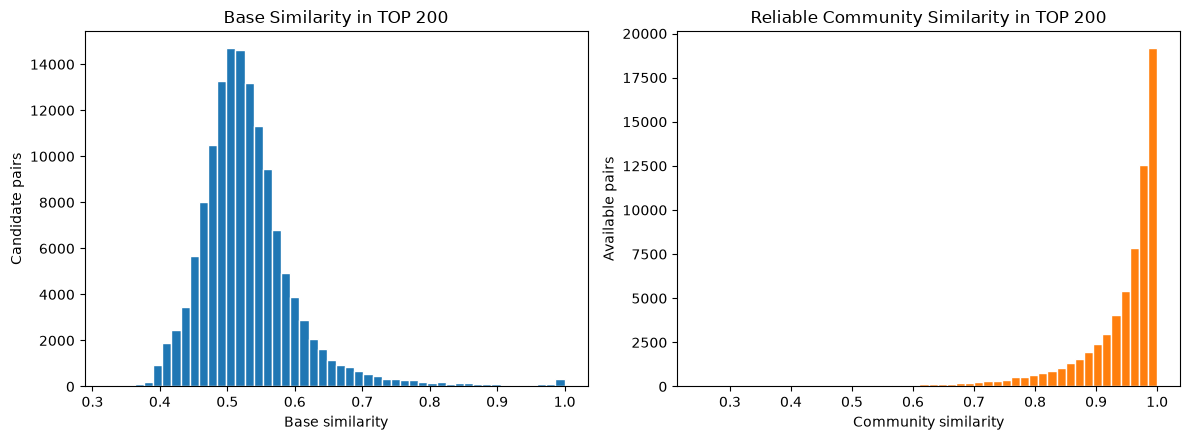

,값
available pair 수,66566.0000
Pearson correlation,0.0942
Spearman correlation,0.0926


Correlation은 성능 지표가 아니라 두 score가 같은 정보를 반복하는지, 보완적인 순위 신호를 갖는지 진단하는 보조 통계다.

In [7]:
base_scale_values = np.concatenate([base_scores_by_query[int(q)] for q in development_query_ids])
community_scale_values = np.concatenate([community_scores_by_query[int(q)] for q in development_query_ids])
available_pair_mask = np.isfinite(community_scale_values)
paired_base_values = base_scale_values[available_pair_mask]
paired_community_values = community_scale_values[available_pair_mask]

def scale_statistics(name, values):
    return {
        "score": name,
        "count": len(values),
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "min": np.min(values),
        "10%": np.quantile(values, 0.10),
        "25%": np.quantile(values, 0.25),
        "median": np.median(values),
        "75%": np.quantile(values, 0.75),
        "90%": np.quantile(values, 0.90),
        "max": np.max(values),
    }

raw_scale_df = pd.DataFrame([
    scale_statistics("Base Similarity", base_scale_values),
    scale_statistics("Community Similarity (available only)", paired_community_values),
])
display(raw_scale_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(base_scale_values, bins=50, edgecolor="white")
axes[0].set(title="Base Similarity in TOP 200", xlabel="Base similarity", ylabel="Candidate pairs")
axes[1].hist(paired_community_values, bins=50, edgecolor="white", color="tab:orange")
axes[1].set(title="Reliable Community Similarity in TOP 200", xlabel="Community similarity", ylabel="Available pairs")
plt.tight_layout()
plt.show()

raw_pearson = pearsonr(paired_base_values, paired_community_values).statistic
raw_spearman = spearmanr(paired_base_values, paired_community_values).statistic
display(pd.Series({
    "available pair 수": len(paired_base_values),
    "Pearson correlation": raw_pearson,
    "Spearman correlation": raw_spearman,
}).to_frame("값").round(4))
display(Markdown("Correlation은 성능 지표가 아니라 두 score가 같은 정보를 반복하는지, 보완적인 순위 신호를 갖는지 진단하는 보조 통계다."))

## 9. Per-query Calibration과 Missing fallback

In [8]:
def minmax_scale(values):
    values = np.asarray(values, dtype=np.float64)
    low, high = values.min(), values.max()
    if np.isclose(high, low):
        return np.full(len(values), 0.5, dtype=np.float64)
    return (values - low) / (high - low)

def zscore_scale(values):
    values = np.asarray(values, dtype=np.float64)
    std = values.std(ddof=0)
    if np.isclose(std, 0.0):
        return np.zeros(len(values), dtype=np.float64)
    return (values - values.mean()) / std

def percentile_scale(values):
    values = np.asarray(values, dtype=np.float64)
    return rankdata(values, method="average") / len(values)

CALIBRATORS = {
    "MINMAX": minmax_scale,
    "ZSCORE": zscore_scale,
    "PERCENTILE": percentile_scale,
}

calibrated_scores = {method: {} for method in METHODS}
sparse_community_query_count = 0
for query_id in development_query_ids:
    query_id = int(query_id)
    base = base_scores_by_query[query_id].astype(np.float64, copy=False)
    community = community_scores_by_query[query_id].astype(np.float64, copy=False)
    available = np.isfinite(community)

    raw_community_with_fallback = base.copy()
    raw_community_with_fallback[available] = community[available]
    calibrated_scores["RAW"][query_id] = {
        "base": base.copy(),
        "community": raw_community_with_fallback,
        "available": available,
        "base_only": False,
    }

    too_sparse = int(available.sum()) < 2
    sparse_community_query_count += int(too_sparse)
    for method, calibrator in CALIBRATORS.items():
        base_calibrated = calibrator(base)
        community_with_fallback = base_calibrated.copy()
        if not too_sparse:
            community_with_fallback[available] = calibrator(community[available])
        calibrated_scores[method][query_id] = {
            "base": base_calibrated,
            "community": community_with_fallback,
            "available": available,
            "base_only": too_sparse,
        }

assert sparse_community_query_count == int((community_counts < 2).sum())
print("Community available candidate가 2개 미만이라 calibrated method에서 Base Ranking만 사용한 query 수:", sparse_community_query_count)
print("모든 방식에서 Community missing candidate의 community score는 해당 candidate의 Base score로 fallback합니다.")

Community available candidate가 2개 미만이라 calibrated method에서 Base Ranking만 사용한 query 수: 6
모든 방식에서 Community missing candidate의 community score는 해당 candidate의 Base score로 fallback합니다.


## 10. Calibration 후 Score Distribution

In [9]:
calibrated_distribution_rows = []
for method in METHODS:
    all_base = np.concatenate([calibrated_scores[method][int(q)]["base"] for q in development_query_ids])
    all_community_available = np.concatenate([
        calibrated_scores[method][int(q)]["community"][calibrated_scores[method][int(q)]["available"]]
        for q in development_query_ids
        if calibrated_scores[method][int(q)]["available"].any()
        and not (method != "RAW" and calibrated_scores[method][int(q)]["base_only"])
    ])
    for feature, values in (("Base", all_base), ("Community (available only)", all_community_available)):
        calibrated_distribution_rows.append({
            "method": method,
            "feature": feature,
            "count": len(values),
            "mean": values.mean(),
            "std": values.std(ddof=1),
            "median": np.median(values),
            "min": values.min(),
            "max": values.max(),
        })

calibrated_distribution_df = pd.DataFrame(calibrated_distribution_rows)
display(calibrated_distribution_df.round(4))

for method in ("MINMAX", "PERCENTILE"):
    part = calibrated_distribution_df[calibrated_distribution_df["method"] == method]
    assert part["min"].min() >= -1e-12 and part["max"].max() <= 1 + 1e-12
z_part = calibrated_distribution_df[calibrated_distribution_df["method"] == "ZSCORE"]
assert np.all(np.abs(z_part["mean"]) < 1e-10)
print("MINMAX / PERCENTILE는 0~1 범위, ZSCORE는 평균 0 근처임을 확인했습니다.")

,method,feature,count,mean,std,median,min,max
0,RAW,Base,140000,0.5310,0.0758,0.5203,0.3223,1.0000
1,RAW,Community (available only),66566,0.9374,0.0803,0.9675,0.2509,1.0000
2,MINMAX,Base,140000,0.1442,0.1784,0.0803,0.0000,1.0000
3,MINMAX,Community (available only),66566,0.8103,0.2142,0.8930,0.0000,1.0000
4,ZSCORE,Base,140000,-0.0000,1.0000,-0.2962,-2.5720,12.6153
5,ZSCORE,Community (available only),66566,0.0000,1.0000,0.3327,-9.1768,2.2008
6,PERCENTILE,Base,140000,0.5025,0.2883,0.5050,0.0050,1.0000
7,PERCENTILE,Community (available only),66566,0.5052,0.2887,0.5052,0.0075,1.0000


MINMAX / PERCENTILE는 0~1 범위, ZSCORE는 평균 0 근처임을 확인했습니다.


## 11. Ranking 보존 검증

In [10]:
rank_check_rng = np.random.default_rng(SEED)
rank_check_query_ids = rank_check_rng.choice(development_query_ids, size=20, replace=False)
rank_preservation_rows = []
for query_id in rank_check_query_ids:
    query_id = int(query_id)
    raw_base = calibrated_scores["RAW"][query_id]["base"]
    raw_community = community_scores_by_query[query_id]
    available = np.isfinite(raw_community)
    for method in CALIBRATED_METHODS:
        item = calibrated_scores[method][query_id]
        rank_preservation_rows.append({
            "query_id": query_id,
            "method": method,
            "Base Spearman": spearmanr(raw_base, item["base"]).statistic,
            "Community Spearman": (
                spearmanr(raw_community[available], item["community"][available]).statistic
                if available.sum() >= 2 and not item["base_only"] else np.nan
            ),
            "community_available": int(available.sum()),
        })

rank_preservation_df = pd.DataFrame(rank_preservation_rows)
display(rank_preservation_df.groupby("method")[["Base Spearman", "Community Spearman"]].agg(["mean", "min"]).round(6))
print("검증 Query ID:", rank_check_query_ids.astype(int).tolist())
print("Min-Max / Z-score는 단조 변환이고 Percentile은 average-rank 동점 처리이므로 원 feature 순서를 보존합니다.")

Base Spearman      Community Spearman     
                    mean  min               mean  min
method                                               
MINMAX               1.0  1.0                1.0  1.0
PERCENTILE           1.0  1.0                1.0  1.0
ZSCORE               1.0  1.0                1.0  1.0

검증 Query ID: [474, 3708, 14318, 105235, 17599, 64258, 113426, 37741, 5717, 69573, 64332, 27695, 103482, 41783, 14681, 85070, 50688, 4036, 71180, 84259]
Min-Max / Z-score는 단조 변환이고 Percentile은 average-rank 동점 처리이므로 원 feature 순서를 보존합니다.


## 12. 평가 함수와 Development 5-Fold CV

In [11]:
def query_metrics(recommended_rows, relevant_ids, k):
    recommended_ids = perfume_ids[recommended_rows[:k]]
    relevance = np.fromiter(
        (int(candidate_id) in relevant_ids for candidate_id in recommended_ids),
        dtype=np.int8, count=len(recommended_ids),
    )
    hits = int(relevance.sum())
    positions = np.flatnonzero(relevance)
    discounts = 1.0 / np.log2(np.arange(2, len(relevance) + 2))
    ideal_length = min(len(relevant_ids), k)
    idcg = float(discounts[:ideal_length].sum())
    return {
        f"Recall@{k}": hits / len(relevant_ids),
        f"HitRate@{k}": float(hits > 0),
        f"MRR@{k}": 1.0 / (positions[0] + 1) if positions.size else 0.0,
        f"NDCG@{k}": float(np.dot(relevance, discounts)) / idcg if idcg > 0 else 0.0,
    }

def per_query_table(rankings):
    rows = []
    for query_id in development_query_ids:
        query_id = int(query_id)
        row = {"query_id": query_id}
        for k in TOP_KS:
            row.update(query_metrics(rankings[query_id], relevant_by_query[query_id], k))
        rows.append(row)
    return pd.DataFrame(rows)

def fold_summary(detail):
    fold_rows = []
    for fold_number, fold_ids in enumerate(cv_folds, start=1):
        part = detail[detail["query_id"].isin(fold_ids)]
        fold_rows.append({"fold": fold_number, **{metric: part[metric].mean() for metric in REPORT_METRICS}})
    fold_df = pd.DataFrame(fold_rows)
    means = {metric: fold_df[metric].mean() for metric in REPORT_METRICS}
    stds = {metric: fold_df[metric].std(ddof=1) for metric in REPORT_METRICS}
    return fold_df, means, stds

def ranking_for_config(query_id, method, gamma, keep=20):
    query_id, gamma = int(query_id), float(gamma)
    candidates = base_candidates[query_id]
    item = calibrated_scores[method][query_id]
    if method != "RAW" and item["base_only"]:
        scores = item["base"]
    else:
        scores = (1.0 - gamma) * item["base"] + gamma * item["community"]
    order = np.lexsort((perfume_ids[candidates], -scores))
    return candidates[order[:keep]]

grid_per_query = {}
grid_fold_results = {}
grid_rows = []
for method in tqdm(METHODS, desc="Calibration methods"):
    for gamma in GAMMAS:
        rankings = {
            int(q): ranking_for_config(int(q), method, float(gamma), keep=20)
            for q in development_query_ids
        }
        detail = per_query_table(rankings)
        fold_df, means, stds = fold_summary(detail)
        key = (method, float(gamma))
        grid_per_query[key] = detail
        grid_fold_results[key] = fold_df
        grid_rows.append({
            "method": method,
            "gamma": float(gamma),
            **{f"{metric} mean": means[metric] for metric in REPORT_METRICS},
            **{f"{metric} std": stds[metric] for metric in REPORT_METRICS},
        })

cv_results_df = pd.DataFrame(grid_rows)
display(cv_results_df.round(4))
print("Final Holdout 평가 query 수: 0")

Calibration methods:   0%|          | 0/4 [00:00<?, ?it/s]

Calibration methods:  25%|██▌       | 1/4 [00:00<00:02,  1.04it/s]

Calibration methods:  50%|█████     | 2/4 [00:01<00:01,  1.14it/s]

Calibration methods:  75%|███████▌  | 3/4 [00:02<00:00,  1.16it/s]

Calibration methods: 100%|██████████| 4/4 [00:03<00:00,  1.23it/s]

Calibration methods: 100%|██████████| 4/4 [00:03<00:00,  1.19it/s]

,method,gamma,Recall@10 mean,HitRate@10 mean,MRR@10 mean,NDCG@10 mean,Recall@20 mean,NDCG@20 mean,Recall@10 std,HitRate@10 std,MRR@10 std,NDCG@10 std,Recall@20 std,NDCG@20 std
0,RAW,0.00,0.3010,0.5657,0.3813,0.2709,0.3500,0.2886,0.0289,0.0533,0.0200,0.0160,0.0229,0.0140
1,RAW,0.05,0.3075,0.5700,0.3906,0.2786,0.3646,0.2993,0.0280,0.0538,0.0224,0.0151,0.0210,0.0120
2,RAW,0.10,0.3153,0.5800,0.4004,0.2859,0.3746,0.3075,0.0257,0.0475,0.0183,0.0142,0.0250,0.0125
3,RAW,0.15,0.3250,0.5871,0.4043,0.2920,0.3814,0.3128,0.0238,0.0415,0.0159,0.0126,0.0250,0.0123
4,RAW,0.20,0.3316,0.6000,0.4108,0.2977,0.3884,0.3185,0.0230,0.0426,0.0155,0.0122,0.0248,0.0127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,PERCENTILE,0.80,0.1526,0.3629,0.1564,0.1131,0.2291,0.1398,0.0231,0.0393,0.0141,0.0135,0.0267,0.0142
80,PERCENTILE,0.85,0.1482,0.3529,0.1564,0.1114,0.2266,0.1385,0.0203,0.0330,0.0142,0.0127,0.0225,0.0124
81,PERCENTILE,0.90,0.1452,0.3443,0.1542,0.1100,0.2170,0.1347,0.0226,0.0351,0.0129,0.0136,0.0207,0.0122
82,PERCENTILE,0.95,0.1361,0.3286,0.1558,0.1072,0.2040,0.1307,0.0254,0.0443,0.0138,0.0146,0.0196,0.0117


Final Holdout 평가 query 수: 0


## 13. 방법별 최적 Gamma

In [12]:
best_method_rows = []
for method in METHODS:
    part = cv_results_df[cv_results_df["method"] == method]
    best = part.sort_values(
        ["NDCG@10 mean", "Recall@10 mean", "MRR@10 mean", "gamma"],
        ascending=[False, False, False, True],
    ).iloc[0]
    best_method_rows.append({
        "method": method,
        "best_gamma": best["gamma"],
        **{metric: best[f"{metric} mean"] for metric in REPORT_METRICS},
    })

best_by_method_df = pd.DataFrame(best_method_rows)
display(best_by_method_df.round(4))

best_calibrated_row = best_by_method_df[best_by_method_df["method"].isin(CALIBRATED_METHODS)].sort_values(
    ["NDCG@10", "Recall@10", "MRR@10", "method"], ascending=[False, False, False, True]
).iloc[0]
best_calibrated_method = str(best_calibrated_row["method"])
best_calibrated_gamma = float(best_calibrated_row["best_gamma"])

display(Markdown("### Best Calibrated Candidate (최종 모델이 아님)"))
display(best_calibrated_row.to_frame("값"))

,method,best_gamma,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
0,RAW,0.7,0.3433,0.6114,0.4453,0.3218,0.3915,0.3396
1,MINMAX,0.7,0.3380,0.6071,0.3925,0.2965,0.3938,0.3167
2,ZSCORE,0.0,0.3010,0.5657,0.3813,0.2709,0.3500,0.2886
3,PERCENTILE,0.0,0.3010,0.5657,0.3813,0.2709,0.3500,0.2886


### Best Calibrated Candidate (최종 모델이 아님)

,값
method,MINMAX
best_gamma,0.7
Recall@10,0.338011
HitRate@10,0.607143
MRR@10,0.392526
NDCG@10,0.296463
Recall@20,0.393756
NDCG@20,0.316705


## 14. Gamma Curve

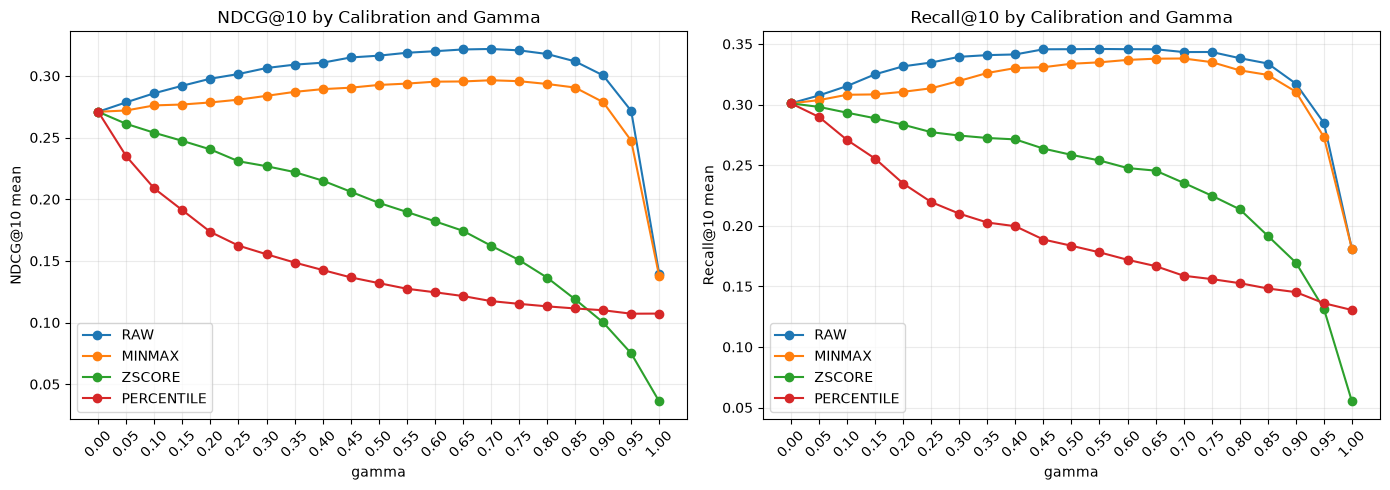

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method in METHODS:
    part = cv_results_df[cv_results_df["method"] == method]
    axes[0].plot(part["gamma"], part["NDCG@10 mean"], marker="o", label=method)
    axes[1].plot(part["gamma"], part["Recall@10 mean"], marker="o", label=method)
axes[0].set(title="NDCG@10 by Calibration and Gamma", xlabel="gamma", ylabel="NDCG@10 mean")
axes[1].set(title="Recall@10 by Calibration and Gamma", xlabel="gamma", ylabel="Recall@10 mean")
for ax in axes:
    ax.set_xticks(GAMMAS)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## 15. Base / Best RAW / Best Calibrated 직접 비교

In [14]:
best_raw_row = best_by_method_df[best_by_method_df["method"] == "RAW"].iloc[0]
best_raw_gamma = float(best_raw_row["best_gamma"])
base_detail = grid_per_query[("RAW", 0.0)]
best_raw_detail = grid_per_query[("RAW", best_raw_gamma)]
best_calibrated_detail = grid_per_query[(best_calibrated_method, best_calibrated_gamma)]

direct_comparison_df = pd.DataFrame([
    {"model": "A. Base Only", "calibration": "RAW", "gamma": 0.0,
     **{metric: base_detail[metric].mean() for metric in REPORT_METRICS}},
    {"model": "B. RAW Community Candidate", "calibration": "RAW", "gamma": best_raw_gamma,
     **{metric: best_raw_detail[metric].mean() for metric in REPORT_METRICS}},
    {"model": "C. Best Calibrated Candidate", "calibration": best_calibrated_method, "gamma": best_calibrated_gamma,
     **{metric: best_calibrated_detail[metric].mean() for metric in REPORT_METRICS}},
])
display(direct_comparison_df.round(4))

,model,calibration,gamma,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
0,A. Base Only,RAW,0.0,0.3010,0.5657,0.3813,0.2709,0.3500,0.2886
1,B. RAW Community Candidate,RAW,0.7,0.3433,0.6114,0.4453,0.3218,0.3915,0.3396
2,C. Best Calibrated Candidate,MINMAX,0.7,0.3380,0.6071,0.3925,0.2965,0.3938,0.3167


## 16. 08 Practical Candidate (RAW gamma=0.7)와 비교

In [15]:
raw_07_detail = grid_per_query[("RAW", 0.7)]
comparison_08_df = pd.DataFrame([
    {
        "metric": metric,
        "08_raw_gamma_0.7": raw_07_detail[metric].mean(),
        "09_calibrated": best_calibrated_detail[metric].mean(),
        "difference": best_calibrated_detail[metric].mean() - raw_07_detail[metric].mean(),
    }
    for metric in REPORT_METRICS
])
display(comparison_08_df.round(4))

,metric,08_raw_gamma_0.7,09_calibrated,difference
0,Recall@10,0.3433,0.3380,-0.0053
1,HitRate@10,0.6114,0.6071,-0.0043
2,MRR@10,0.4453,0.3925,-0.0528
3,NDCG@10,0.3218,0.2965,-0.0254
4,Recall@20,0.3915,0.3938,0.0022
5,NDCG@20,0.3396,0.3167,-0.0229


## 17. Fold Stability: Best Calibrated - RAW gamma=0.7

In [16]:
raw_07_fold_df = grid_fold_results[("RAW", 0.7)]
best_calibrated_fold_df = grid_fold_results[(best_calibrated_method, best_calibrated_gamma)]
fold_metrics = ["Recall@10", "HitRate@10", "MRR@10", "NDCG@10"]
fold_difference_df = best_calibrated_fold_df[["fold", *fold_metrics]].copy()
fold_difference_df[fold_metrics] = best_calibrated_fold_df[fold_metrics] - raw_07_fold_df[fold_metrics]
display(fold_difference_df.round(4))

fold_direction_df = pd.DataFrame([
    {
        "metric": metric,
        "개선 Fold 수": int((fold_difference_df[metric] > 1e-12).sum()),
        "하락 Fold 수": int((fold_difference_df[metric] < -1e-12).sum()),
        "동일 Fold 수": int((np.abs(fold_difference_df[metric]) <= 1e-12).sum()),
    }
    for metric in fold_metrics
])
display(fold_direction_df)

,fold,Recall@10,HitRate@10,MRR@10,NDCG@10
0,1,0.0004,0.0071,-0.0475,-0.0217
1,2,-0.0107,-0.0214,-0.0366,-0.0210
2,3,-0.0084,-0.0071,-0.0321,-0.0164
3,4,-0.0134,-0.0286,-0.0623,-0.0297
4,5,0.0056,0.0286,-0.0853,-0.0382


,metric,개선 Fold 수,하락 Fold 수,동일 Fold 수
0,Recall@10,2,3,0
1,HitRate@10,2,3,0
2,MRR@10,0,5,0
3,NDCG@10,0,5,0


## 18. Paired Bootstrap: RAW gamma=0.7 vs Best Calibrated

In [17]:
def paired_bootstrap(reference_detail, candidate_detail, metrics, label):
    rng = np.random.default_rng(SEED)
    rows = []
    reference_indexed = reference_detail.set_index("query_id").loc[development_query_ids]
    candidate_indexed = candidate_detail.set_index("query_id").loc[development_query_ids]
    for metric in metrics:
        differences = candidate_indexed[metric].to_numpy() - reference_indexed[metric].to_numpy()
        indices = rng.integers(0, len(differences), size=(BOOTSTRAP_RESAMPLES, len(differences)))
        bootstrap_means = differences[indices].mean(axis=1)
        lower, upper = np.quantile(bootstrap_means, [0.025, 0.975])
        rows.append({
            "comparison": label,
            "metric": metric,
            "mean_difference": differences.mean(),
            "ci_2.5%": lower,
            "ci_97.5%": upper,
            "CI_includes_zero": bool(lower <= 0 <= upper),
        })
    return pd.DataFrame(rows)

bootstrap_08_df = paired_bootstrap(
    raw_07_detail, best_calibrated_detail, ("Recall@10", "NDCG@10"),
    "Best Calibrated - RAW gamma=0.7",
)
display(bootstrap_08_df.round(4))

,comparison,metric,mean_difference,ci_2.5%,ci_97.5%,CI_includes_zero
0,Best Calibrated - RAW gamma=0.7,Recall@10,-0.0053,-0.0132,0.0025,True
1,Best Calibrated - RAW gamma=0.7,NDCG@10,-0.0254,-0.0325,-0.0186,False


## 19. Base Only 대비 Community 효과

In [18]:
bootstrap_base_df = paired_bootstrap(
    base_detail, best_calibrated_detail, ("Recall@10", "NDCG@10"),
    "Best Calibrated - Base Only",
)
display(bootstrap_base_df.round(4))

,comparison,metric,mean_difference,ci_2.5%,ci_97.5%,CI_includes_zero
0,Best Calibrated - Base Only,Recall@10,0.0370,0.0239,0.0498,False
1,Best Calibrated - Base Only,NDCG@10,0.0256,0.0167,0.0346,False


## 20. Best RAW 대비 Calibration 효과와 practical rule

In [19]:
bootstrap_best_raw_df = paired_bootstrap(
    best_raw_detail, best_calibrated_detail, ("Recall@10", "NDCG@10"),
    "Best Calibrated - Best RAW",
)
display(bootstrap_best_raw_df.round(4))

best_raw_ndcg = float(best_raw_detail["NDCG@10"].mean())
best_calibrated_ndcg = float(best_calibrated_detail["NDCG@10"].mean())
calibration_gain = best_calibrated_ndcg - best_raw_ndcg
best_raw_ndcg_bootstrap = bootstrap_best_raw_df.set_index("metric").loc["NDCG@10"]
prefer_raw_for_simplicity = (
    calibration_gain <= 0
    or (
        calibration_gain < PRACTICAL_TOLERANCE
        and bool(best_raw_ndcg_bootstrap["CI_includes_zero"])
    )
)
print(f"Best Calibration - Best RAW NDCG@10: {calibration_gain:+.6f}")
print(f"Practical tolerance: {PRACTICAL_TOLERANCE:.3f} (이 프로젝트의 단순성 판단 기준이며 통계 기준이 아님)")
print("단순성 규칙에 따라 RAW 유지 권고:", prefer_raw_for_simplicity)

,comparison,metric,mean_difference,ci_2.5%,ci_97.5%,CI_includes_zero
0,Best Calibrated - Best RAW,Recall@10,-0.0053,-0.0132,0.0025,True
1,Best Calibrated - Best RAW,NDCG@10,-0.0254,-0.0325,-0.0186,False


Best Calibration - Best RAW NDCG@10: -0.025384
Practical tolerance: 0.002 (이 프로젝트의 단순성 판단 기준이며 통계 기준이 아님)
단순성 규칙에 따라 RAW 유지 권고: True


## 21. Popularity Robustness

In [20]:
popularity_frame = pd.DataFrame({
    "query_id": development_query_ids.astype(int),
    "popularity": popularity[development_rows],
}).dropna()

popularity_robustness_rows = []
if popularity_frame["popularity"].nunique() >= 4:
    popularity_frame["quartile"] = pd.qcut(
        popularity_frame["popularity"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
    )
    for quartile in popularity_frame["quartile"].cat.categories:
        ids = popularity_frame.loc[popularity_frame["quartile"] == quartile, "query_id"].astype(int)
        row = {"popularity_quartile": str(quartile), "query_count": len(ids)}
        for label, detail in (
            ("Base Only", base_detail),
            ("RAW gamma=0.7", raw_07_detail),
            ("Best Calibrated", best_calibrated_detail),
        ):
            part = detail[detail["query_id"].isin(ids)]
            row[f"{label} Recall@10"] = part["Recall@10"].mean()
            row[f"{label} NDCG@10"] = part["NDCG@10"].mean()
        popularity_robustness_rows.append(row)
    popularity_robustness_df = pd.DataFrame(popularity_robustness_rows)
    display(popularity_robustness_df.round(4))
else:
    print("고유 popularity 값이 4개 미만이라 4분위 분석을 수행하지 않습니다.")

,popularity_quartile,query_count,Base Only Recall@10,Base Only NDCG@10,RAW gamma=0.7 Recall@10,RAW gamma=0.7 NDCG@10,Best Calibrated Recall@10,Best Calibrated NDCG@10
0,Q1,175,0.3043,0.2604,0.3430,0.3021,0.3326,0.2761
1,Q2,175,0.2497,0.2239,0.3138,0.2684,0.2960,0.2479
2,Q3,175,0.2991,0.2651,0.3200,0.3064,0.3287,0.2887
3,Q4,175,0.3509,0.3342,0.3965,0.4105,0.3948,0.3732


## 22. Community Coverage별 분석

In [21]:
coverage_frame = pd.DataFrame({
    "query_id": development_query_ids.astype(int),
    "community_coverage": [
        np.isfinite(community_scores_by_query[int(q)]).mean() for q in development_query_ids
    ],
})
coverage_frame["coverage_group"] = pd.qcut(
    coverage_frame["community_coverage"].rank(method="first"),
    q=3, labels=["A. 낮음", "B. 중간", "C. 높음"]
)

coverage_rows = []
for group in ["A. 낮음", "B. 중간", "C. 높음"]:
    part_info = coverage_frame[coverage_frame["coverage_group"] == group]
    ids = part_info["query_id"].astype(int)
    raw_part = raw_07_detail[raw_07_detail["query_id"].isin(ids)]
    calibrated_part = best_calibrated_detail[best_calibrated_detail["query_id"].isin(ids)]
    coverage_rows.append({
        "coverage_group": group,
        "query_count": len(ids),
        "coverage_min": part_info["community_coverage"].min(),
        "coverage_median": part_info["community_coverage"].median(),
        "coverage_max": part_info["community_coverage"].max(),
        "RAW gamma=0.7 Recall@10": raw_part["Recall@10"].mean(),
        "Best Calibrated Recall@10": calibrated_part["Recall@10"].mean(),
        "RAW gamma=0.7 NDCG@10": raw_part["NDCG@10"].mean(),
        "Best Calibrated NDCG@10": calibrated_part["NDCG@10"].mean(),
    })
coverage_analysis_df = pd.DataFrame(coverage_rows)
display(coverage_analysis_df.round(4))

,coverage_group,query_count,coverage_min,coverage_median,coverage_max,RAW gamma=0.7 Recall@10,Best Calibrated Recall@10,RAW gamma=0.7 NDCG@10,Best Calibrated NDCG@10
0,A. 낮음,234,0.000,0.405,0.450,0.2898,0.2827,0.2681,0.2405
1,B. 중간,233,0.450,0.480,0.515,0.3534,0.3417,0.3325,0.3017
2,C. 높음,233,0.515,0.560,0.665,0.3870,0.3899,0.3652,0.3474


## 23. Ranking 변화 사례

In [22]:
def full_ranking(query_id, method, gamma):
    return ranking_for_config(query_id, method, gamma, keep=CANDIDATE_POOL)

case_records = []
for query_id in development_query_ids:
    query_id = int(query_id)
    raw_ranking = full_ranking(query_id, "RAW", 0.7)
    calibrated_ranking = full_ranking(query_id, best_calibrated_method, best_calibrated_gamma)
    raw_ranks = {int(perfume_ids[row]): i for i, row in enumerate(raw_ranking, start=1)}
    calibrated_ranks = {int(perfume_ids[row]): i for i, row in enumerate(calibrated_ranking, start=1)}
    candidates = base_candidates[query_id]
    candidate_position = {int(perfume_ids[row]): i for i, row in enumerate(candidates)}
    calibrated_item = calibrated_scores[best_calibrated_method][query_id]

    for relevant_id in relevant_by_query[query_id]:
        relevant_id = int(relevant_id)
        if relevant_id not in candidate_position:
            continue
        raw_rank = raw_ranks[relevant_id]
        calibrated_rank = calibrated_ranks[relevant_id]
        improvement = raw_rank - calibrated_rank
        if improvement == 0:
            continue
        pos = candidate_position[relevant_id]
        query_row, relevant_row = id_to_row[query_id], id_to_row[relevant_id]
        case_records.append({
            "direction": "improved" if improvement > 0 else "harmed",
            "query perfume": perfume_names[query_row],
            "brand": perfume_brands[query_row],
            "Relevant perfume": perfume_names[relevant_row],
            "Raw rank": raw_rank,
            "Calibrated rank": calibrated_rank,
            "rank improvement": improvement,
            "raw base similarity": base_scores_by_query[query_id][pos],
            "raw community similarity": community_scores_by_query[query_id][pos],
            "calibrated base score": calibrated_item["base"][pos],
            "calibrated community score": calibrated_item["community"][pos],
        })

ranking_cases_df = pd.DataFrame(case_records)
display(Markdown("### Best Calibrated가 순위를 개선한 Relevant Item (최대 10개)"))
display(ranking_cases_df[ranking_cases_df["direction"] == "improved"].sort_values(
    ["rank improvement", "query perfume"], ascending=[False, True]
).drop(columns="direction").head(10).round(4))
display(Markdown("### Best Calibrated에서 순위가 하락한 Relevant Item (최대 10개)"))
display(ranking_cases_df[ranking_cases_df["direction"] == "harmed"].sort_values(
    ["rank improvement", "query perfume"], ascending=[True, True]
).drop(columns="direction").head(10).round(4))
print("Base TOP 200 밖의 Relevant Item은 두 reranker 모두 순위를 바꿀 수 없어 사례 표에서 제외했습니다.")

### Best Calibrated가 순위를 개선한 Relevant Item (최대 10개)

,query perfume,brand,Relevant perfume,Raw rank,Calibrated rank,rank improvement,raw base similarity,raw community similarity,calibrated base score,calibrated community score
20,Sole di Positano,Tom Ford,Soul of Amalfi,116,1,115,0.7541,NaN,1.0000,1.0000
325,Oranger Alhambra,Giorgio Armani,Cologne 1888,108,9,99,0.6509,NaN,0.8040,0.8040
51,Silver Light Man,Linn Young,A-Star for Men,99,3,96,0.7672,NaN,0.8482,0.8482
125,Italica (2021),Casamorati 1888,Beautello,99,6,93,0.7130,NaN,0.7788,0.7788
80,Sensual Amber,Bath & Body Works,Bergamot Amber,81,1,80,0.7725,NaN,1.0000,1.0000
513,Amour Céleste,Guerlain,Jardin de l'Élysée,76,14,62,0.6456,0.8958,1.0000,0.6487
529,Emporio Armani Stronger With You Parfum,Giorgio Armani,Proud Of You,62,3,59,0.7511,NaN,0.7950,0.7950
392,Aqua Allegoria Ginger Piccante,Guerlain,Rouge Bonheur 2025 Millésime,60,8,52,0.7618,0.8665,1.0000,0.6724
647,Amore Caffè,Mancera,Café Arabica,105,60,45,0.6550,NaN,0.6732,0.6732
60,Fakhar Extrait,Lattafa Perfumes,Fakhar Gold,52,11,41,0.5224,0.9214,0.7798,0.8606


### Best Calibrated에서 순위가 하락한 Relevant Item (최대 10개)

,query perfume,brand,Relevant perfume,Raw rank,Calibrated rank,rank improvement,raw base similarity,raw community similarity,calibrated base score,calibrated community score
416,Wood Sage & Sea Salt,Jo Malone London,Salted Breeze,11,81,-70,0.6554,0.9281,0.6491,0.5172
184,Oud Wood,Tom Ford,Sweet Oud,27,91,-64,0.7857,0.9178,0.5908,0.6386
90,Muguet Millésime 2018,Guerlain,Muguet Millésime 2020,15,71,-56,0.8147,0.9352,0.5741,0.4453
287,Quelques Fleurs Jardin Secret,Houbigant,Quelques Fleurs Jardin Secret Extrait,3,53,-50,0.7851,0.8986,0.8303,0.6022
650,Invictus,Rabanne,Vamos Crescent,6,54,-48,0.9301,0.9610,0.8976,0.5004
483,Angels' Share,By Kilian,Mystic Dream,38,82,-44,0.6158,0.9653,0.2409,0.7968
519,Womanity,Mugler,Womanity Liqueurs de Parfum,13,57,-44,0.6945,0.9223,0.5102,0.6463
488,Angels' Share,By Kilian,Zaya,50,92,-42,0.6072,0.9600,0.2218,0.7653
658,Chanel No 5 Eau de Parfum,Chanel,Chanel No 5 Eau Premiere (2015),15,54,-39,0.7027,0.9384,0.4017,0.7625
91,Muguet Millésime 2018,Guerlain,Muguet 2024,48,87,-39,0.7462,0.9193,0.4143,0.3045


Base TOP 200 밖의 Relevant Item은 두 reranker 모두 순위를 바꿀 수 없어 사례 표에서 제외했습니다.


## 24. Calibration 방법 해석

In [23]:
best_raw_fold_df = grid_fold_results[("RAW", best_raw_gamma)]
cal_vs_raw_fold_df = best_calibrated_fold_df[["fold", *fold_metrics]].copy()
cal_vs_raw_fold_df[fold_metrics] = best_calibrated_fold_df[fold_metrics] - best_raw_fold_df[fold_metrics]
cal_vs_raw_improved_folds = int((cal_vs_raw_fold_df["NDCG@10"] > 1e-12).sum())
cal_vs_raw_ndcg_ci = bootstrap_best_raw_df.set_index("metric").loc["NDCG@10"]

if calibration_gain > PRACTICAL_TOLERANCE and cal_vs_raw_improved_folds >= 3 and cal_vs_raw_ndcg_ci["ci_2.5%"] > 0:
    calibration_case = "A"
    calibration_conclusion = (
        "Raw Score Scale 차이가 기존 reranking을 일부 왜곡하고 있었으며, calibration이 더 안정적인 결합을 제공했다."
    )
elif calibration_gain < 0:
    calibration_case = "C"
    calibration_conclusion = (
        "현재 raw score의 상대적 값 차이 자체가 ranking에 유용한 신호로 작동했을 가능성이 있으며, 단순 calibration은 그 정보를 제거했다."
    )
else:
    calibration_case = "B"
    calibration_conclusion = (
        "Score Scale 차이는 존재하지만 현재 ranking 성능을 실질적으로 왜곡하는 정도는 제한적이다."
    )

display(Markdown(f'''
### Calibration 판단: Case {calibration_case}

{calibration_conclusion}

- Best Calibrated - Best RAW NDCG@10: **{calibration_gain:+.4f}**
- NDCG@10 개선 Fold 수: **{cal_vs_raw_improved_folds}/5**
- Paired bootstrap 95% CI: **[{cal_vs_raw_ndcg_ci['ci_2.5%']:.4f}, {cal_vs_raw_ndcg_ci['ci_97.5%']:.4f}]**
- CI가 0을 포함: **{cal_vs_raw_ndcg_ci['CI_includes_zero']}**

이 결론은 feature 중요도의 인과적 차이를 뜻하지 않는다.
'''))


### Calibration 판단: Case C

현재 raw score의 상대적 값 차이 자체가 ranking에 유용한 신호로 작동했을 가능성이 있으며, 단순 calibration은 그 정보를 제거했다.

- Best Calibrated - Best RAW NDCG@10: **-0.0254**
- NDCG@10 개선 Fold 수: **0/5**
- Paired bootstrap 95% CI: **[-0.0325, -0.0186]**
- CI가 0을 포함: **False**

이 결론은 feature 중요도의 인과적 차이를 뜻하지 않는다.


## 25. Community 효과 자체의 판단

In [24]:
base_lookup = bootstrap_base_df.set_index("metric")
community_recall_gain = best_calibrated_detail["Recall@10"].mean() - base_detail["Recall@10"].mean()
community_ndcg_gain = best_calibrated_detail["NDCG@10"].mean() - base_detail["NDCG@10"].mean()
community_supported = (
    community_recall_gain > 0
    and community_ndcg_gain > 0
    and base_lookup.loc["NDCG@10", "ci_2.5%"] > 0
)

if community_supported:
    community_conclusion = (
        "Season / Daypart Community Perception은 score scale 차이를 제거한 뒤에도 향 구조 정보에 추가적인 ranking signal을 제공했다."
    )
else:
    community_conclusion = (
        "Score scale을 보정한 뒤 Community feature가 Base보다 안정적인 추가 이득을 준다는 근거는 이번 Development 분석에서 충분하지 않다."
    )

display(Markdown(f'''
### Base Only와 분리한 결론

{community_conclusion}

- Recall@10 차이: **{community_recall_gain:+.4f}**
- NDCG@10 차이: **{community_ndcg_gain:+.4f}**
- Recall@10 bootstrap CI: **[{base_lookup.loc['Recall@10', 'ci_2.5%']:.4f}, {base_lookup.loc['Recall@10', 'ci_97.5%']:.4f}]**
- NDCG@10 bootstrap CI: **[{base_lookup.loc['NDCG@10', 'ci_2.5%']:.4f}, {base_lookup.loc['NDCG@10', 'ci_97.5%']:.4f}]**
'''))


### Base Only와 분리한 결론

Season / Daypart Community Perception은 score scale 차이를 제거한 뒤에도 향 구조 정보에 추가적인 ranking signal을 제공했다.

- Recall@10 차이: **+0.0370**
- NDCG@10 차이: **+0.0256**
- Recall@10 bootstrap CI: **[0.0239, 0.0498]**
- NDCG@10 bootstrap CI: **[0.0167, 0.0346]**


## 26. Gamma 경계와 해석 규칙

In [25]:
boundary_rows = []
for row in best_by_method_df.itertuples(index=False):
    boundary = bool(np.isclose(row.best_gamma, 0.0) or np.isclose(row.best_gamma, 1.0))
    boundary_rows.append({"method": row.method, "best_gamma": row.best_gamma, "boundary": boundary})
    if boundary:
        print(f"경고: {row.method} best gamma={row.best_gamma:.2f}는 탐색 경계입니다.")
display(pd.DataFrame(boundary_rows))

if np.isclose(best_calibrated_gamma, 1.0):
    print("Best Calibrated gamma=1.0이어도 Community가 Base보다 본질적으로 중요하다는 뜻은 아닙니다.")
    print("Candidate는 Base retrieval로 생성되므로 TOP 200 밖의 향수는 Community가 검색할 수 없습니다.")
print("gamma는 현재 score 표현에서 Development ranking 성능을 최적화한 결합 계수입니다.")

경고: ZSCORE best gamma=0.00는 탐색 경계입니다.
경고: PERCENTILE best gamma=0.00는 탐색 경계입니다.


,method,best_gamma,boundary
0,RAW,0.7,False
1,MINMAX,0.7,False
2,ZSCORE,0.0,True
3,PERCENTILE,0.0,True


gamma는 현재 score 표현에서 Development ranking 성능을 최적화한 결합 계수입니다.


## 27. 최종 요약

In [26]:
raw_scale_lookup = raw_scale_df.set_index("score")
best_lookup = best_by_method_df.set_index("method")
best_calibrated_lookup = direct_comparison_df.set_index("model").loc["C. Best Calibrated Candidate"]
base_model_lookup = direct_comparison_df.set_index("model").loc["A. Base Only"]
raw_model_lookup = direct_comparison_df.set_index("model").loc["B. RAW Community Candidate"]
bootstrap_08_lookup = bootstrap_08_df.set_index("metric")

if prefer_raw_for_simplicity:
    calibration_needed_text = (
        "아니오 — calibration이 RAW보다 하락했거나 추가 복잡도의 실익이 제한적이므로 RAW 유지 권고"
    )
    recommended_method = "RAW"
    recommended_gamma = best_raw_gamma
else:
    calibration_needed_text = f"{best_calibrated_method}가 Development 기준으로 실질적 이득을 보여 후보로 유지"
    recommended_method = best_calibrated_method
    recommended_gamma = best_calibrated_gamma

summary_markdown = f'''
## Raw Score Scale

Base:
- mean: **{raw_scale_lookup.loc['Base Similarity', 'mean']:.4f}**
- median: **{raw_scale_lookup.loc['Base Similarity', 'median']:.4f}**
- std: **{raw_scale_lookup.loc['Base Similarity', 'std']:.4f}**

Community:
- mean: **{raw_scale_lookup.loc['Community Similarity (available only)', 'mean']:.4f}**
- median: **{raw_scale_lookup.loc['Community Similarity (available only)', 'median']:.4f}**
- std: **{raw_scale_lookup.loc['Community Similarity (available only)', 'std']:.4f}**

Base / Community correlation:
- Pearson: **{raw_pearson:.4f}**
- Spearman: **{raw_spearman:.4f}**

## Calibration Results

RAW:
- best gamma: **{best_lookup.loc['RAW', 'best_gamma']:.2f}**
- Recall@10: **{best_lookup.loc['RAW', 'Recall@10']:.4f}**
- NDCG@10: **{best_lookup.loc['RAW', 'NDCG@10']:.4f}**

MINMAX:
- best gamma: **{best_lookup.loc['MINMAX', 'best_gamma']:.2f}**
- Recall@10: **{best_lookup.loc['MINMAX', 'Recall@10']:.4f}**
- NDCG@10: **{best_lookup.loc['MINMAX', 'NDCG@10']:.4f}**

ZSCORE:
- best gamma: **{best_lookup.loc['ZSCORE', 'best_gamma']:.2f}**
- Recall@10: **{best_lookup.loc['ZSCORE', 'Recall@10']:.4f}**
- NDCG@10: **{best_lookup.loc['ZSCORE', 'NDCG@10']:.4f}**

PERCENTILE:
- best gamma: **{best_lookup.loc['PERCENTILE', 'best_gamma']:.2f}**
- Recall@10: **{best_lookup.loc['PERCENTILE', 'Recall@10']:.4f}**
- NDCG@10: **{best_lookup.loc['PERCENTILE', 'NDCG@10']:.4f}**

## Best Calibrated Candidate

- method: **{best_calibrated_method}**
- gamma: **{best_calibrated_gamma:.2f}**
- Recall@10: **{best_calibrated_lookup['Recall@10']:.4f}**
- HitRate@10: **{best_calibrated_lookup['HitRate@10']:.4f}**
- MRR@10: **{best_calibrated_lookup['MRR@10']:.4f}**
- NDCG@10: **{best_calibrated_lookup['NDCG@10']:.4f}**

## RAW vs Calibration

- Recall@10 difference (Best Calibrated - Best RAW): **{best_calibrated_lookup['Recall@10'] - raw_model_lookup['Recall@10']:+.4f}**
- NDCG@10 difference (Best Calibrated - Best RAW): **{best_calibrated_lookup['NDCG@10'] - raw_model_lookup['NDCG@10']:+.4f}**
- Recall bootstrap CI: **[{bootstrap_best_raw_df.set_index('metric').loc['Recall@10', 'ci_2.5%']:.4f}, {bootstrap_best_raw_df.set_index('metric').loc['Recall@10', 'ci_97.5%']:.4f}]**
- NDCG bootstrap CI: **[{bootstrap_best_raw_df.set_index('metric').loc['NDCG@10', 'ci_2.5%']:.4f}, {bootstrap_best_raw_df.set_index('metric').loc['NDCG@10', 'ci_97.5%']:.4f}]**
- NDCG@10 개선 Fold 수: **{cal_vs_raw_improved_folds}/5**

## Base vs Calibrated Community

- Base Recall@10: **{base_model_lookup['Recall@10']:.4f}**
- Community Recall@10: **{best_calibrated_lookup['Recall@10']:.4f}**
- Base NDCG@10: **{base_model_lookup['NDCG@10']:.4f}**
- Community NDCG@10: **{best_calibrated_lookup['NDCG@10']:.4f}**
- Recall CI: **[{base_lookup.loc['Recall@10', 'ci_2.5%']:.4f}, {base_lookup.loc['Recall@10', 'ci_97.5%']:.4f}]**
- NDCG CI: **[{base_lookup.loc['NDCG@10', 'ci_2.5%']:.4f}, {base_lookup.loc['NDCG@10', 'ci_97.5%']:.4f}]**

## 현재 판단

- Score Calibration이 필요한지: **{calibration_needed_text}**
- 추천 Calibration 방식: **{recommended_method}**
- 추천 gamma: **{recommended_gamma:.2f}**
- Community 효과가 Scale 차이 이후에도 유지되는지: **{community_conclusion}**
- Candidate Pool: **200 고정**
- 향수 취향 추천 구조를 확정할 수 있는지: **아직 아님 — Development 분석 후보이며 Final Holdout 최종 검증 전**
- Final Holdout은 아직 사용하지 않았는지: **예 — candidate 생성 및 평가 0건**

참고로 08 RAW gamma=0.7 대비 Best Calibrated의 NDCG@10 차이는 **{comparison_08_df.set_index('metric').loc['NDCG@10', 'difference']:+.4f}**, bootstrap CI는 **[{bootstrap_08_lookup.loc['NDCG@10', 'ci_2.5%']:.4f}, {bootstrap_08_lookup.loc['NDCG@10', 'ci_97.5%']:.4f}]**다.

Final Holdout 300개는 끝까지 사용하지 않았다. Best Calibrated Candidate는 **Development CV 기준 후보**이며 최종 모델이 아니다.
'''
display(Markdown(summary_markdown))
print("Final Holdout candidate 생성 수:", sum(int(q) in base_candidates for q in final_holdout_query_ids))
print("Final Holdout 평가 query 수: 0")


## Raw Score Scale

Base:
- mean: **0.5310**
- median: **0.5203**
- std: **0.0758**

Community:
- mean: **0.9374**
- median: **0.9675**
- std: **0.0803**

Base / Community correlation:
- Pearson: **0.0942**
- Spearman: **0.0926**

## Calibration Results

RAW:
- best gamma: **0.70**
- Recall@10: **0.3433**
- NDCG@10: **0.3218**

MINMAX:
- best gamma: **0.70**
- Recall@10: **0.3380**
- NDCG@10: **0.2965**

ZSCORE:
- best gamma: **0.00**
- Recall@10: **0.3010**
- NDCG@10: **0.2709**

PERCENTILE:
- best gamma: **0.00**
- Recall@10: **0.3010**
- NDCG@10: **0.2709**

## Best Calibrated Candidate

- method: **MINMAX**
- gamma: **0.70**
- Recall@10: **0.3380**
- HitRate@10: **0.6071**
- MRR@10: **0.3925**
- NDCG@10: **0.2965**

## RAW vs Calibration

- Recall@10 difference (Best Calibrated - Best RAW): **-0.0053**
- NDCG@10 difference (Best Calibrated - Best RAW): **-0.0254**
- Recall bootstrap CI: **[-0.0132, 0.0025]**
- NDCG bootstrap CI: **[-0.0325, -0.0186]**
- NDCG@10 개선 Fold 수: **0/5**

## Base vs Calibrated Community

- Base Recall@10: **0.3010**
- Community Recall@10: **0.3380**
- Base NDCG@10: **0.2709**
- Community NDCG@10: **0.2965**
- Recall CI: **[0.0239, 0.0498]**
- NDCG CI: **[0.0167, 0.0346]**

## 현재 판단

- Score Calibration이 필요한지: **아니오 — calibration이 RAW보다 하락했거나 추가 복잡도의 실익이 제한적이므로 RAW 유지 권고**
- 추천 Calibration 방식: **RAW**
- 추천 gamma: **0.70**
- Community 효과가 Scale 차이 이후에도 유지되는지: **Season / Daypart Community Perception은 score scale 차이를 제거한 뒤에도 향 구조 정보에 추가적인 ranking signal을 제공했다.**
- Candidate Pool: **200 고정**
- 향수 취향 추천 구조를 확정할 수 있는지: **아직 아님 — Development 분석 후보이며 Final Holdout 최종 검증 전**
- Final Holdout은 아직 사용하지 않았는지: **예 — candidate 생성 및 평가 0건**

참고로 08 RAW gamma=0.7 대비 Best Calibrated의 NDCG@10 차이는 **-0.0254**, bootstrap CI는 **[-0.0325, -0.0186]**다.

Final Holdout 300개는 끝까지 사용하지 않았다. Best Calibrated Candidate는 **Development CV 기준 후보**이며 최종 모델이 아니다.


Final Holdout candidate 생성 수: 0
Final Holdout 평가 query 수: 0
